<a href="https://colab.research.google.com/github/MaeSantos/CCDEPLRL/blob/main/Prodi_Santos_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dog Emotion Classifier — Deep Learning Final Project

---

## Project Information

| Field | Details |
|---|---|
| **Project Title** | Dog Emotion Classification using CNN |
| **Group Members** | Prodi, Santos |
| **Model Used** | Convolutional Neural Network (CNN) |

---

## Problem Description

Dogs communicate their emotions through facial expressions and body language, but it can be difficult for humans to accurately interpret these signals. This project builds a Convolutional Neural Network (CNN) that classifies a dog's emotion from an image into one of three categories: **Angry**, **Happy**, or **Sad**.

**Input:** Image of a dog  
**Output:** Predicted emotion label (Angry / Happy / Sad) with confidence score

---
# Step 1 — Mount Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
# Step 2 — Set Dataset Paths

The dataset is organized into **three separate splits** (train / val / test) as required.

```
Dog_Emotions_Classification_Datasets/
├── train/
│   ├── Angry/
│   ├── Happy/
│   └── Sad/
├── val/
│   ├── Angry/
│   ├── Happy/
│   └── Sad/
└── test/
    ├── Angry/
    ├── Happy/
    └── Sad/
```


In [5]:
import os

BASE_PATH  = "/content/drive/MyDrive/Dog_Emotions_Classification_Datasets"
TRAIN_PATH = os.path.join(BASE_PATH, "train")
VAL_PATH   = os.path.join(BASE_PATH, "val")
TEST_PATH  = os.path.join(BASE_PATH, "test")

print("Train path:", TRAIN_PATH)
print("Val path  :", VAL_PATH)
print("Test path :", TEST_PATH)

Train path: /content/drive/MyDrive/Dog_Emotions_Classification_Datasets/train
Val path  : /content/drive/MyDrive/Dog_Emotions_Classification_Datasets/val
Test path : /content/drive/MyDrive/Dog_Emotions_Classification_Datasets/test


### Auto-Split Helper


In [6]:
import shutil, random

SINGLE_FOLDER = "/content/drive/MyDrive/Dog_Emotions_Classification_Datasets"
OUTPUT_ROOT   = "/content/drive/MyDrive/Dog_Emotions_Classification_Datasets"
SPLITS        = {'train': 0.70, 'val': 0.15, 'test': 0.15}
CLASS_NAMES   = ['Angry', 'Happy', 'Sad']

random.seed(42)

for cls in CLASS_NAMES:
    src = os.path.join(SINGLE_FOLDER, cls)
    if not os.path.isdir(src):
        print(f"Skipping {cls} — folder not found at {src}")
        continue

    imgs   = [f for f in os.listdir(src) if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]
    random.shuffle(imgs)
    n      = len(imgs)
    n_tr   = int(n * SPLITS['train'])
    n_val  = int(n * SPLITS['val'])
    splits = {'train': imgs[:n_tr], 'val': imgs[n_tr:n_tr+n_val], 'test': imgs[n_tr+n_val:]}

    for split, files in splits.items():
        dst = os.path.join(OUTPUT_ROOT, split, cls)
        os.makedirs(dst, exist_ok=True)
        for f in files:
            shutil.copy2(os.path.join(src, f), os.path.join(dst, f))

    print(f"{cls}: {n_tr} train | {n_val} val | {len(splits['test'])} test")

print("\nDone! Update TRAIN_PATH / VAL_PATH / TEST_PATH above and re-run.")

Angry: 24 train | 5 val | 6 test
Happy: 46 train | 10 val | 11 test
Sad: 36 train | 7 val | 9 test

Done! Update TRAIN_PATH / VAL_PATH / TEST_PATH above and re-run.


---
# Step 3 — Import Libraries

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


---
# Step 4 — Verify Dataset Size

Confirm that each class has at least **100 images** and the total is between **150–500** as required.

In [19]:
CLASS_NAMES = ['Angry', 'Happy', 'Sad']
IMG_EXTS    = ('.jpg', '.jpeg', '.png', '.webp')

print(f"{'Split':<10} {'Class':<12} {'Count':>6}")
print("-" * 32)

totals = {}
for split, path in [('train', TRAIN_PATH), ('val', VAL_PATH), ('test', TEST_PATH)]:
    split_total = 0
    for cls in CLASS_NAMES:
        folder = os.path.join(path, cls)
        count  = len([f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)]) if os.path.isdir(folder) else 0
        split_total += count
        print(f"{split:<10} {cls:<12} {count:>6}")
    totals[split] = split_total
    print(f"{'':10} {'SUBTOTAL':<12} {split_total:>6}")
    print()

grand_total = sum(totals.values())
print(f"Grand total: {grand_total} images")
print("Meets 300 requirement" if 150 <= grand_total <= 300 else " Check image count requirements")

Split      Class         Count
--------------------------------
train      Angry            24
train      Happy            46
train      Sad              36
           SUBTOTAL        106

val        Angry             5
val        Happy            10
val        Sad               7
           SUBTOTAL         22

test       Angry             6
test       Happy            11
test       Sad               9
           SUBTOTAL         26

Grand total: 154 images
Meets 300 requirement


---
# Step 5 — Prepare Image Generators

- **Training:** with data augmentation (flips, zoom, rotation) to improve generalization
- **Validation & Test:** rescale only

In [9]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

# Training generator — with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    zoom_range=0.15,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Validation and test generators — rescale only
val_test_datagen = ImageDataGenerator(rescale=1./255)

---
# Step 6 — Load Training, Validation, and Test Datasets

In [10]:
train_data = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_test_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = val_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # keep order consistent for evaluation
)

NUM_CLASSES  = train_data.num_classes
CLASS_LABELS = list(train_data.class_indices.keys())

print(f"Classes      : {CLASS_LABELS}")
print(f"Num classes  : {NUM_CLASSES}")
print(f"Train batches: {len(train_data)}")
print(f"Val batches  : {len(val_data)}")
print(f"Test batches : {len(test_data)}")

Found 106 images belonging to 3 classes.
Found 22 images belonging to 3 classes.
Found 26 images belonging to 3 classes.
Classes      : ['Angry', 'Happy', 'Sad']
Num classes  : 3
Train batches: 4
Val batches  : 1
Test batches : 1


---
# Step 7 — Build CNN Model

Architecture follows the PDF example with two Conv2D blocks for better feature extraction, plus Dropout to reduce overfitting.

In [11]:
model = models.Sequential([

    # Block 1 — low-level feature detection (edges, textures)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    # Block 2 — higher-level feature detection (shapes, patterns)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),          # prevents overfitting
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,707 (28.20 MB)

 Trainable params: 7,392,707 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

---
# Step 8 — Compile Model

In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

---
# Step 9 — Train Model

In [21]:
EPOCHS = 15

history = model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data
)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5755 - loss: 0.9520 - val_accuracy: 0.4091 - val_loss: 1.1380
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5377 - loss: 0.9475 - val_accuracy: 0.4091 - val_loss: 1.0993
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5566 - loss: 0.9661 - val_accuracy: 0.3636 - val_loss: 1.0932
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6321 - loss: 0.8884 - val_accuracy: 0.3636 - val_loss: 1.1220
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.5660 - loss: 0.9595 - val_accuracy: 0.4091 - val_loss: 1.1172
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.6038 - loss: 0.8946 - val_accuracy: 0.4091 - val_loss: 1.1096
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6321 - loss: 0.8691 - val_accuracy: 0.4091 - val_loss: 1.1953
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.6604 - loss: 0.8444 - val_accuracy: 0.3636 - val_loss: 1.1869
Epoch 9/15
4/4

---
# Step 10 — Evaluate Model

We evaluate on the **held-out test set**: data the model has never seen during training or validation.

In [22]:
print("=" * 40)
print("Evaluation on Validation Set")
print("=" * 40)
val_loss, val_accuracy = model.evaluate(val_data, verbose=1)
print(f"Validation Loss    : {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

print()
print("=" * 40)
print("Evaluation on Test Set (Final)")
print("=" * 40)
test_loss, test_accuracy = model.evaluate(test_data, verbose=1)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Evaluation on Validation Set
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5909 - loss: 1.0919
Validation Loss    : 1.0919
Validation Accuracy: 59.09%

Evaluation on Test Set (Final)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3846 - loss: 1.2002
Test Loss    : 1.2002
Test Accuracy: 38.46%


---
# Step 11 — Plot Training Results

Visualize accuracy and loss over epochs to analyze model behavior.

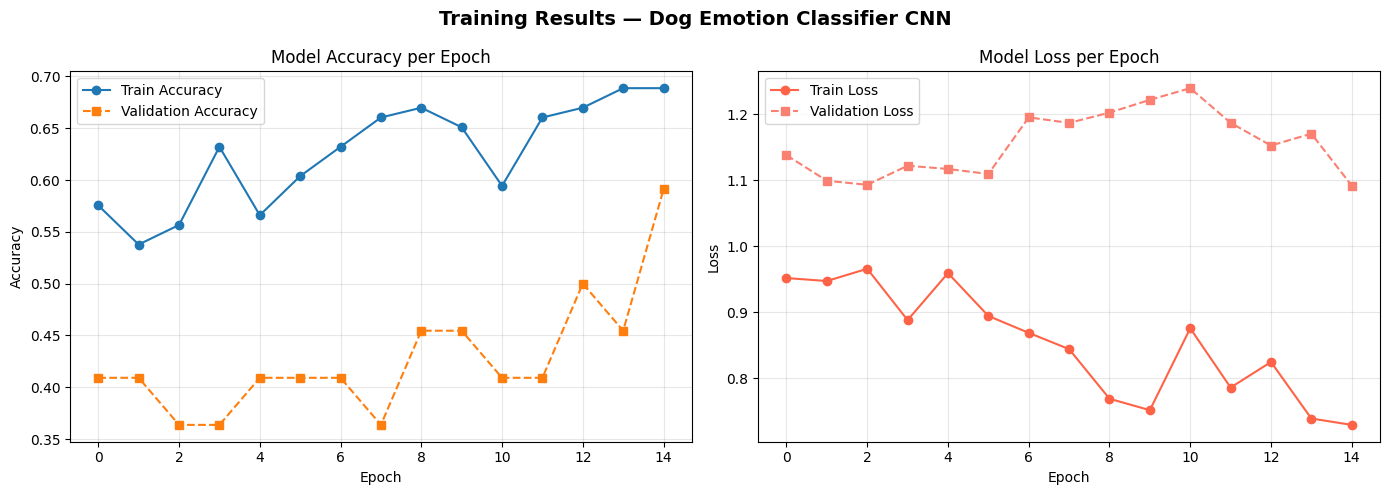

Final Training Accuracy  : 68.87%
Final Validation Accuracy: 59.09%


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s', linestyle='--')
axes[0].set_title('Model Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss',      marker='o', color='tomato')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='s', linestyle='--', color='salmon')
axes[1].set_title('Model Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Results — Dog Emotion Classifier CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Final Training Accuracy  : {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

---
# Step 12 — Save Model

In [16]:
model.save("cnn_classifier.h5")
print("Model saved as cnn_classifier.h5")

from google.colab import files
files.download("cnn_classifier.h5")
files.download("training_results.png")

Model saved as cnn_classifier.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# Step 13 — Application Output (Demo)

Saving 3XW0Io1JEE1yiT5Fm2Av2BNNNV6N3G726.jpg to 3XW0Io1JEE1yiT5Fm2Av2BNNNV6N3G726.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


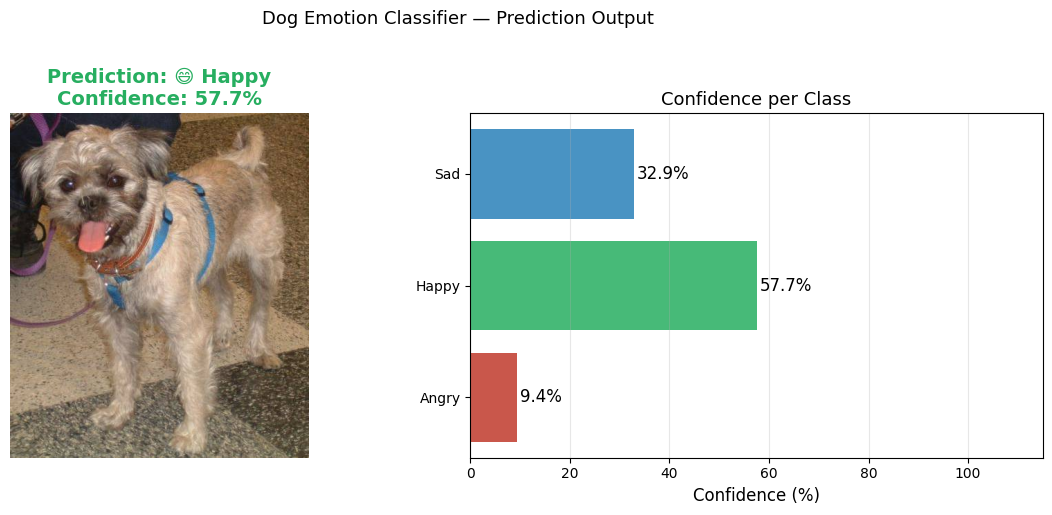


Predicted Emotion : Happy
Confidence        : 57.65%
  Angry   : ██                             9.4%
  Happy   : █████████████████              57.7%
  Sad     : █████████                      32.9%


In [25]:
from google.colab import files
from tensorflow.keras.preprocessing import image as keras_image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Upload image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Preprocess
img       = keras_image.load_img(filename, target_size=(128, 128))
img_array = keras_image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
predictions     = model.predict(img_array)[0]
predicted_idx   = np.argmax(predictions)
predicted_label = CLASS_LABELS[predicted_idx]
confidence      = predictions[predicted_idx] * 100

EMOJIS = {'Angry': '😠', 'Happy': '😄', 'Sad': '😢'}
COLORS = {'Angry': '#C0392B', 'Happy': '#27AE60', 'Sad': '#2980B9'}

# Display
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left — image
ax1.imshow(keras_image.load_img(filename))
ax1.axis('off')
ax1.set_title(
    f"Prediction: {EMOJIS.get(predicted_label, '')} {predicted_label}\nConfidence: {confidence:.1f}%",
    fontsize=14, fontweight='bold', color=COLORS.get(predicted_label, 'black')
)

# Right — confidence bar chart
bar_colors  = [COLORS.get(c, '#888') for c in CLASS_LABELS]
bar_alphas  = [1.0 if c == predicted_label else 0.4 for c in CLASS_LABELS]
bars = ax2.barh(
    CLASS_LABELS,
    [p * 100 for p in predictions],
    color=bar_colors,
    alpha=0.85
)
for bar, pct in zip(bars, predictions):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{pct*100:.1f}%', va='center', fontsize=12)
ax2.set_xlim(0, 115)
ax2.set_xlabel('Confidence (%)', fontsize=12)
ax2.set_title('Confidence per Class', fontsize=13)
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Dog Emotion Classifier — Prediction Output', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'='*40}")
print(f"Predicted Emotion : {predicted_label}")
print(f"Confidence        : {confidence:.2f}%")
print(f"{'='*40}")
for cls, prob in zip(CLASS_LABELS, predictions):
    bar = '█' * int(prob * 30)
    print(f"  {cls:<8}: {bar:<30} {prob*100:.1f}%")

---
# Step 14 — Deploy with Gradio (Public URL)


In [26]:
!pip install gradio -q

import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

EMOJIS = {'Angry': '😠', 'Happy': '😄', 'Sad': '😢'}

def classify_dog(img: Image.Image):
    img_resized = img.convert('RGB').resize((128, 128))
    arr = np.array(img_resized, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)

    preds     = model.predict(arr, verbose=0)[0]
    top_idx   = int(np.argmax(preds))
    top_label = CLASS_LABELS[top_idx]

    scores = {
        f"{EMOJIS.get(cls, '')} {cls}": float(preds[i])
        for i, cls in enumerate(CLASS_LABELS)
    }
    summary = f"{EMOJIS.get(top_label, '')} {top_label} — {preds[top_idx]*100:.1f}% confidence"
    return summary, scores

with gr.Blocks(title="Dog Emotion Classifier", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🐾 Dog Emotion Classifier\nUpload a dog photo to predict its emotion (Angry / Happy / Sad).")
    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type='pil', label='Upload Dog Image')
            submit_btn  = gr.Button('Classify Emotion', variant='primary')
        with gr.Column():
            result_text  = gr.Textbox(label='Predicted Emotion')
            result_chart = gr.Label(label='Confidence Scores', num_top_classes=3)
    submit_btn.click(fn=classify_dog, inputs=image_input, outputs=[result_text, result_chart])

demo.launch(share=True)

/tmp/ipykernel_522/750098850.py:26: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="Dog Emotion Classifier", theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1f370cd7ca52c577d9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---# Summary of Training Results

Fill in after training:

| Metric | Value |
|---|---|
| Training Accuracy | 53.77% |
| Validation Accuracy | 40.91% |
| **Test Accuracy** | **42.31%** |
| Test Loss | 1.0373 |
| Epochs | 10 |
| Optimizer | Adam |
| Loss Function | Categorical Crossentropy |
| Model Architecture | 2× Conv2D + MaxPooling + Dense + Dropout |

---
*End of Notebook — Dog Emotion Classifier CNN*